In [ ]:
!pip -q install lifelines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.5 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel('/content/Kosmetik 2024 - Copy.xlsx', sheet_name='Rekap (2)')
df.head(1)

,No,Balai / Unit,Nomor Manual,Sampel,SPU,SP,SPS,SPK,Nomor Surat Tugas,Tanggal Sampling,...,Komoditi,Unnamed: 32,Status,Operator,Verifikasi Oleh,Tanggal,UPT Penyampling,Kesimpulan Uji,Kesimpulan Penandaan,Kesimpulan Akhir (sesuai inputan MT)
0,1,BALAI BESAR POM DI SURABAYA,K/001/ACAK/2024/K,24.096.201.12.01.0001.K,SPU.096.01.24.01.12.0004,SP.096.24.02.06.12.0004,SPS.096.01.24.02.12.0004,SPK.096.24.02.12.0026,PW.03.12.15A.15A2.01.24.142,16/01/2024,...,Kosmetika,» Krim Malam (night Cream),Selesai,Muhammad Haris Pamungkas,"Ditwas Kosmetik - Direktur (Irwan, S.Si., Apt....",2024-04-05 00:00:00,BALAI BESAR POM DI SURABAYA,Hasil Uji Kimia : MS,MK,Memenuhi Syarat


In [ ]:
selected_columns = df[['Tanggal Sampling', 'Tanggal', 'Kesimpulan Akhir (sesuai inputan MT)']]
display(selected_columns.head())

,Tanggal Sampling,Tanggal,Kesimpulan Akhir (sesuai inputan MT)
0,16/01/2024,2024-04-05 00:00:00,Memenuhi Syarat
1,16/01/2024,2024-04-05 00:00:00,Memenuhi Syarat
2,16/01/2024,26 Maret 2024,Memenuhi Syarat
3,16/01/2024,2024-04-05 00:00:00,Memenuhi Syarat
4,16/01/2024,2024-04-05 00:00:00,Memenuhi Syarat


In [ ]:
bulan_id = {
    "Januari": "January",
    "Februari": "February",
    "Maret": "March",
    "April": "April",
    "Mei": "May",
    "Juni": "June",
    "Juli": "July",
    "Agustus": "August",
    "September": "September",
    "Oktober": "October",
    "November": "November",
    "Desember": "December"}

def parse_tanggal(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x).strip()
    for id_bulan, en_bulan in bulan_id.items():
        x = x.replace(id_bulan, en_bulan)
    return pd.to_datetime(x, errors="coerce", dayfirst=True)

In [ ]:
selected_columns["Tanggal Sampling"] = selected_columns["Tanggal Sampling"].apply(parse_tanggal)
selected_columns["Tanggal"] = selected_columns["Tanggal"].apply(parse_tanggal)

/tmp/ipython-input-3272010112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns["Tanggal Sampling"] = selected_columns["Tanggal Sampling"].apply(parse_tanggal)
/tmp/ipython-input-862793788.py:21: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, errors="coerce", dayfirst=True)
/tmp/ipython-input-3272010112.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  

In [ ]:
selected_columns["Durasi Sampling"] = (selected_columns["Tanggal"] - selected_columns["Tanggal Sampling"]).dt.days
selected_columns

/tmp/ipython-input-932962092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns["Durasi Sampling"] = (selected_columns["Tanggal"] - selected_columns["Tanggal Sampling"]).dt.days


,Tanggal Sampling,Tanggal,Kesimpulan Akhir (sesuai inputan MT),Durasi Sampling
0,2024-01-16,2024-05-04,Memenuhi Syarat,109
1,2024-01-16,2024-05-04,Memenuhi Syarat,109
2,2024-01-16,2024-03-26,Memenuhi Syarat,70
3,2024-01-16,2024-05-04,Memenuhi Syarat,109
4,2024-01-16,2024-05-04,Memenuhi Syarat,109
...,...,...,...,...
1072,2024-10-11,2024-12-31,Memenuhi Syarat,81
1073,2024-09-11,2024-12-31,Memenuhi Syarat,111
1074,2024-09-11,2024-12-31,Memenuhi Syarat,111
1075,2024-11-12,2024-12-30,Memenuhi Syarat,48


In [ ]:
selected_columns['Durasi Sampling'].describe()

,Durasi Sampling
count,1077.000000
mean,114.404828
std,51.686551
min,29.000000
25%,74.000000
50%,104.000000
75%,149.000000
max,269.000000


In [ ]:
d = selected_columns.dropna(subset=['Tanggal Sampling', 'Tanggal', 'Kesimpulan Akhir (sesuai inputan MT)']).copy()
d["T"] = (d['Tanggal'] - d['Tanggal Sampling']).dt.days
d = d[(d["T"] > 0) & (d["T"] < 3650)].copy()
d["E"] = 1

In [ ]:
summary = (d.groupby('Kesimpulan Akhir (sesuai inputan MT)')["T"]
           .agg(
               n="count",
               mean="mean",
               median="median",
               p90=lambda x: float(np.quantile(x, 0.90)),
               min="min",
               max="max"
           )
           .reset_index()
           .sort_values("median", ascending=False))

display(summary)

,Kesimpulan Akhir (sesuai inputan MT),n,mean,median,p90,min,max
0,Memenuhi Syarat,1006,116.158052,105.0,197.0,29,269
1,Tidak Memenuhi Syarat,71,89.563380,94.0,131.0,29,248


<Figure size 1000x400 with 0 Axes>

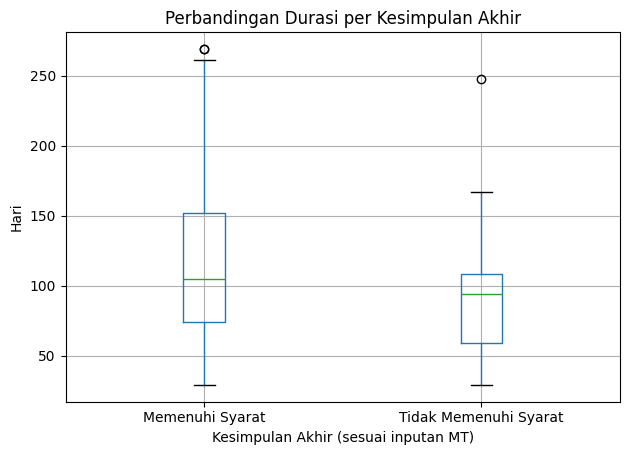

In [ ]:
order = summary['Kesimpulan Akhir (sesuai inputan MT)'].tolist()

d_plot = d.copy()
d_plot['Kesimpulan Akhir (sesuai inputan MT)'] = pd.Categorical(d_plot['Kesimpulan Akhir (sesuai inputan MT)'], categories=order, ordered=True)

plt.figure(figsize=(10,4))
d_plot.boxplot(column="T", by='Kesimpulan Akhir (sesuai inputan MT)', rot=0)
plt.title("Perbandingan Durasi per Kesimpulan Akhir")
plt.suptitle("")
plt.xlabel("Kesimpulan Akhir (sesuai inputan MT)")
plt.ylabel("Hari")
plt.tight_layout()
plt.show()

In [ ]:
selected_columns.groupby('Kesimpulan Akhir (sesuai inputan MT)')['Durasi Sampling'].median()

,Durasi Sampling
Kesimpulan Akhir (sesuai inputan MT),
Memenuhi Syarat,105.0
Tidak Memenuhi Syarat,94.0


/tmp/ipython-input-2821117032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Kesimpulan Akhir (sesuai inputan MT)', y='median', data=summary, palette='spring')


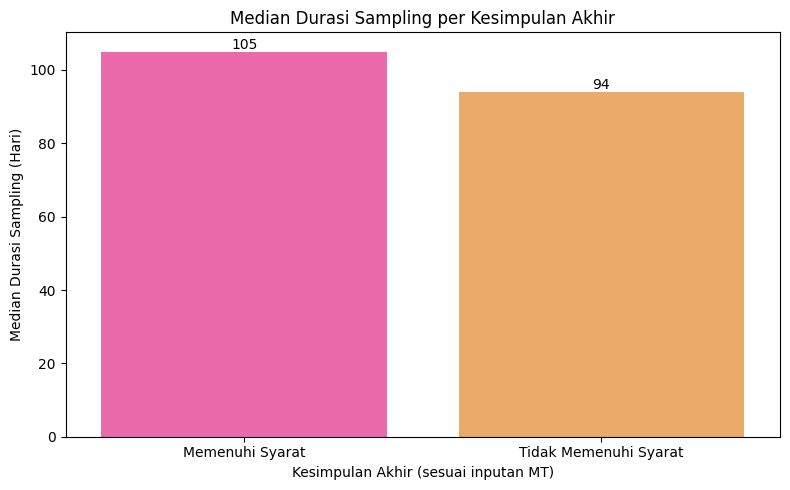

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Kesimpulan Akhir (sesuai inputan MT)', y='median', data=summary, palette='spring')
plt.title('Median Durasi Sampling per Kesimpulan Akhir')
plt.xlabel('Kesimpulan Akhir (sesuai inputan MT)')
plt.ylabel('Median Durasi Sampling (Hari)')
plt.xticks(rotation=0, ha='center')

# Add numerical labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

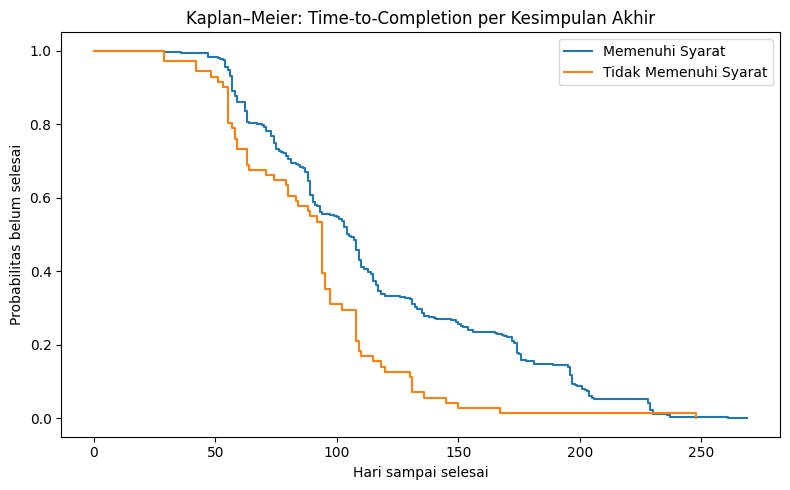

In [ ]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,5))
for g, sub in d.groupby('Kesimpulan Akhir (sesuai inputan MT)'):
    kmf.fit(durations=sub["T"], event_observed=sub["E"], label=str(g))
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan–Meier: Time-to-Completion per Kesimpulan Akhir")
plt.xlabel("Hari sampai selesai")
plt.ylabel("Probabilitas belum selesai")
plt.tight_layout()
plt.show()

In [ ]:
lr = multivariate_logrank_test(d["T"], d['Kesimpulan Akhir (sesuai inputan MT)'], d["E"])
print(lr.summary)

   test_statistic         p   -log2(p)
0       21.080131  0.000004  17.792519


In [ ]:
cox = d[["T", "E", 'Kesimpulan Akhir (sesuai inputan MT)']].copy()

# one-hot baseline otomatis adalah kategori pertama yang “ter-drop” oleh drop_first
X = pd.get_dummies(cox['Kesimpulan Akhir (sesuai inputan MT)'], drop_first=True)

cox_input = pd.concat([cox[["T","E"]], X], axis=1)

cph = CoxPHFitter()
cph.fit(cox_input, duration_col="T", event_col="E")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1077 total observations, 0 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 1077
number of events observed = 1077
   partial log-likelihood = -6438.63
         time fit was run = 2025-12-18 17:28:02 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
Tidak Memenuhi Syarat  0.55      1.73      0.12            0.30            0.79                1.35                2.20

                       cmp to    z      p  -log2(p)
covariate                                          
Tidak Memenuhi Syarat    0.00 4.39 <0.005     16.46
---
Concordance = 0.52
Partial AIC = 12879.26
log-likelihood ratio test = 16.64 on 1 df
-log2(p) of ll-ratio test = 14.44

In [ ]:
out = cph.summary.copy()
out["HR"] = np.exp(out["coef"])
out = out.sort_values("HR", ascending=False)

display(out[["HR","coef","p","exp(coef) lower 95%","exp(coef) upper 95%"]])

print("\nCara baca:")
print("- HR > 1  : kelompok tsb cenderung lebih cepat selesai dibanding baseline")
print("- HR < 1  : kelompok tsb cenderung lebih lambat selesai dibanding baseline")
print("- p < 0.05: perbedaan relatif signifikan (indikasi kuat)")

,HR,coef,p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,
Tidak Memenuhi Syarat,1.725914,0.545757,0.000011,1.352995,2.201619



Cara baca:
- HR > 1  : kelompok tsb cenderung lebih cepat selesai dibanding baseline
- HR < 1  : kelompok tsb cenderung lebih lambat selesai dibanding baseline
- p < 0.05: perbedaan relatif signifikan (indikasi kuat)



   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.8268)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7620)'>]]

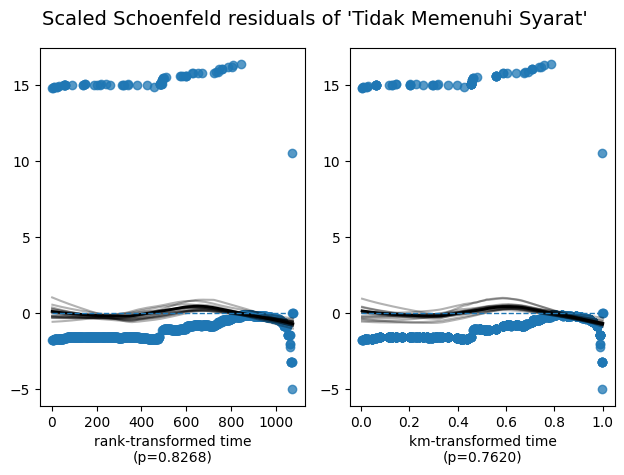

In [ ]:
cph.check_assumptions(cox_input, p_value_threshold=0.05, show_plots=True)